hiposenter inversi:
[[ 1000.0095765 ]
 [-5500.00912782]]
Error: 0.0000036178


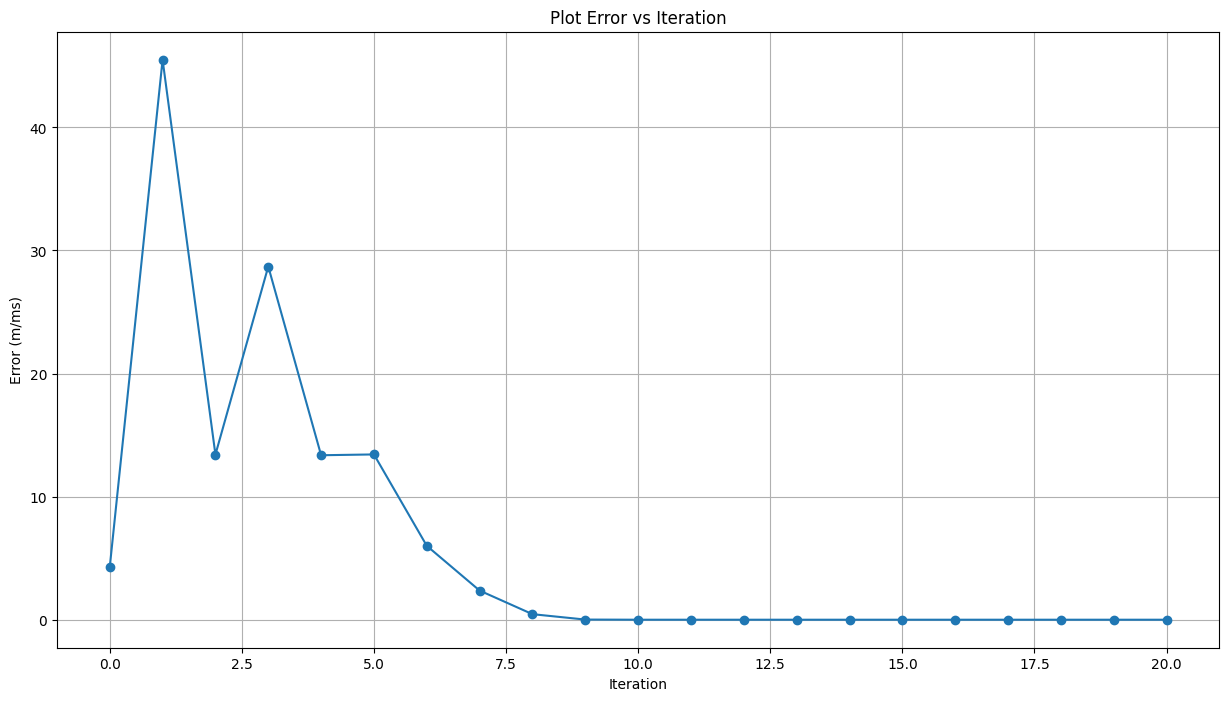

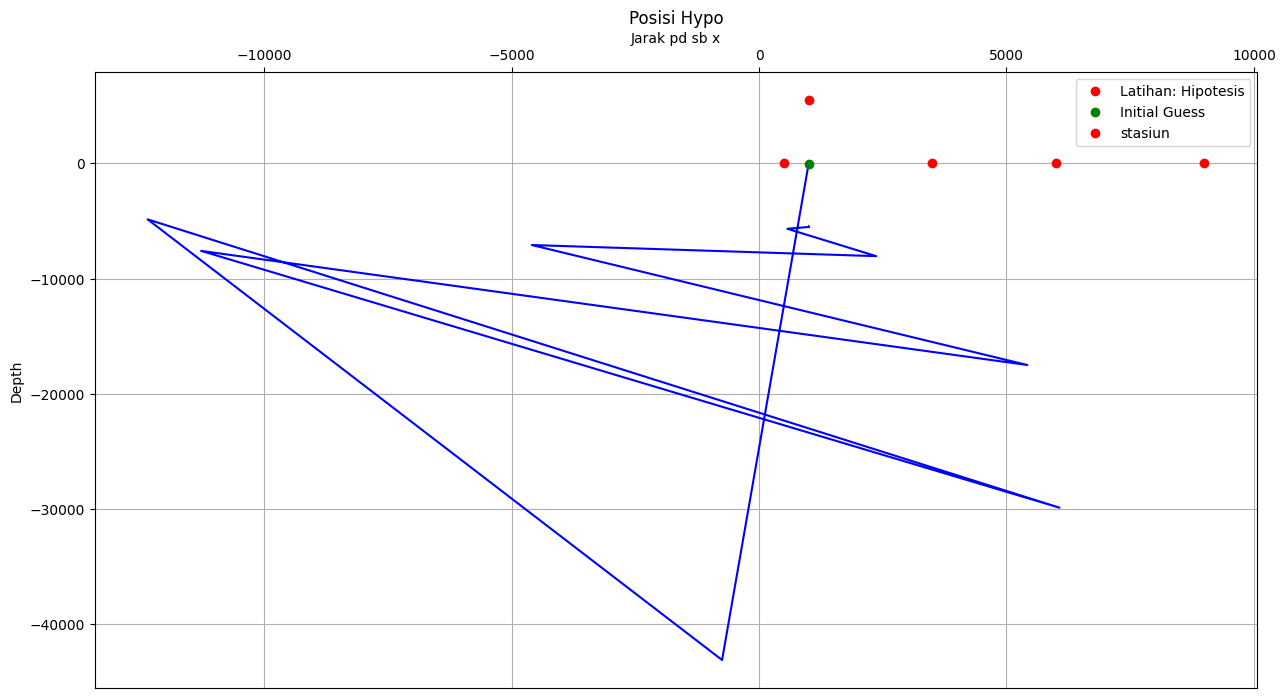

In [1]:
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt

# forward model
def forward_model(x, z, m, v):
    t = []
    for i in range(len(x)):
        t.append(np.sqrt((m[0] - x[i])**2 + (m[1] - z[i])**2) / v)
    return np.array(t).reshape(len(t), 1)

def jacobian(x, z, m, v):
    j = np.zeros((len(x), 2))
    for i in range(len(x)):
        j[i, 0] = (m[0].item() - x[i]) / np.sqrt((m[0].item() - x[i])**2 + (m[1].item() - z[i])**2) / v  # kolom pertama
        j[i, 1] = (m[1].item() - z[i]) / np.sqrt((m[0].item() - x[i])**2 + (m[1].item() - z[i])**2) / v  # kolom kedua
    return j

def rmse(d, g_m):
    return np.sqrt(np.sum((g_m - d)**2) / len(d))

def inversi_linier(st_x, st_z, m, v, d, iterasi):
    i = 0
    J = jacobian(st_x, st_z, m, v) # Changed 'j' to 'J'
    g_m = forward_model(st_x, st_z, m, v)
    g_m = g_m.reshape(len(g_m), 1)

    error_history = []
    error = rmse(g_m, d)
    error_history.append(error)
    m_history = [m.reshape(2, 1)]
    i_history = []
    i_history.append(i)

    for i in range(iterasi):
        i += 1
        i_history.append(i)

        m = m.reshape(2, 1) + inv(J.T @ J) @ J.T @ (d - g_m)  # persamaan
        J = jacobian(st_x, st_z, m, v)

        g_m = forward_model(st_x, st_z, m, v)
        g_m = g_m.reshape(len(g_m), 1)

        error = rmse(d, g_m)
        error_history.append(error)

        m_history.append(m)

    return m, m_history, error_history, i_history
    # Posisi Stasiun
# Converting st_x and st_z to 1D arrays
st_x = np.array([500, 3500, 6000, 9000])
st_z = np.array([0, 0, 0, 0])

# waktu gelombang
waktu_gel = np.array([6.9033664, 7.55190373, 9.29129297, 12.13530491])  # hasil forward dari (1000, -5800)
d = waktu_gel.reshape(len(waktu_gel), 1)
v = 800

# Tebakan awal
m0 = np.array([1000, -80])
iterasi = 20
E = 0.001
I = np.eye(2)

# Inversi linier
hypo, hypo_history, error_history, iterasi_history = inversi_linier(
    st_x, st_z, m0, v, d, iterasi
)  # panggil fungsi

print("hiposenter inversi:")
print(hypo)
print(f"Error: {error_history[-1]:.10f}")

plt.figure(figsize=(15, 8))
plt.plot(iterasi_history, error_history, 'o-')
plt.title('Plot Error vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Error (m/ms)')
plt.grid()
plt.show()

hypo_history_array = np.array(hypo_history) # Changed 'hypo_history_result' to 'hypo_history'
plt.figure(figsize=(15, 8))
plt.plot(hypo_history_array[:, 0], hypo_history_array[:, 1], 'b-')
plt.plot(1000, 5500, 'o', color='red', label='Latihan: Hipotesis')
plt.plot(m0[0], m0[1], 'o', color='green', label='Initial Guess') # Corrected label
plt.plot(st_x, st_z, 'o', color='red', label='stasiun')
plt.title("Posisi Hypo")
plt.xlabel("Jarak pd sb x")
plt.ylabel("Depth")
plt.legend()
plt.grid()
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()
plt.show()

Permasalahan 1

Konvergen di iterasi ke-4

HASIL
True Hypo : (12, 10)
Estimasi  : (11.8389, 9.9038)
Error     : 0.002367


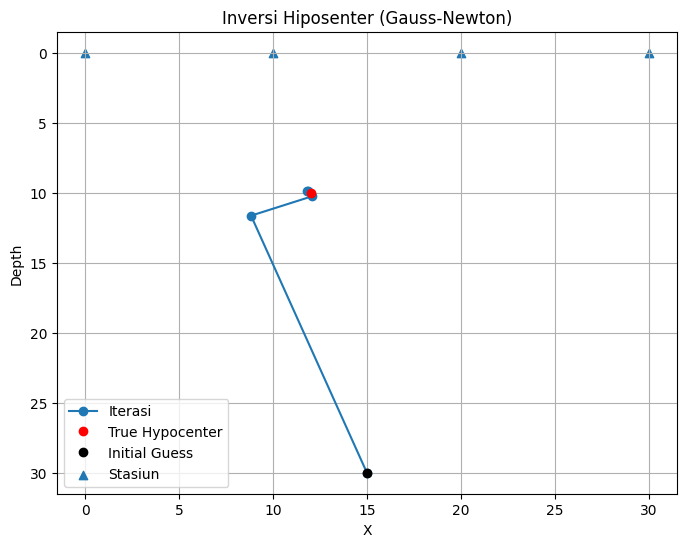

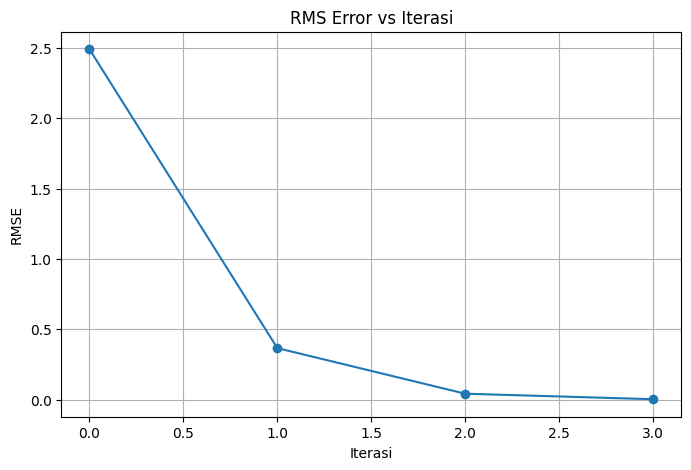

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# DATA
x = np.array([0, 10, 20, 30])
z = np.array([0, 0, 0, 0])
n = len(x)

# True hypocenter
xo, zo, t0 = 12, 10, 0
v = 7

# FORWARD MODEL
def forward(x, z, m):
    t = []
    for i in range(n):
        r = np.sqrt((x[i] - m[0])**2 + (z[i] - m[1])**2)
        t.append(r / v)
    return np.array(t)

# data observasi
t_true = forward(x, z, [xo, zo])

# noise 1%
noise = np.random.normal(0, 0.01*np.mean(t_true), n)
t_obs = t_true + noise


# JACOBIAN
def jacobian(x, z, m):
    J = np.zeros((n, 2))
    for i in range(n):
        r = np.sqrt((x[i] - m[0])**2 + (z[i] - m[1])**2)
        J[i,0] = (-(x[i] - m[0])) / (v * r)
        J[i,1] = (-(z[i] - m[1])) / (v * r)
    return J

# RMSE
def rmse(d, g):
    return np.sqrt(np.mean((d - g)**2))

# INVERSI GAUSS-NEWTON
m = np.array([15, 30])  # tebakan awal
max_iter = 4
target_error = 1e-2

m_hist = [m.copy()]
err_hist = []

for i in range(max_iter):
    g = forward(x, z, m)
    J = jacobian(x, z, m)

    r = t_obs - g

    # update model
    dm = np.linalg.inv(J.T @ J) @ J.T @ r
    m = m + dm

    # simpan
    m_hist.append(m.copy())
    err = rmse(t_obs, g)
    err_hist.append(err)

    if err < target_error:
        print(f"Konvergen di iterasi ke-{i+1}")
        break

# OUTPUT
print("\nHASIL")
print(f"True Hypo : ({xo}, {zo})")
print(f"Estimasi  : ({m[0]:.4f}, {m[1]:.4f})")
print(f"Error     : {err_hist[-1]:.6f}")

# PLOT
m_hist = np.array(m_hist)

plt.figure(figsize=(8,6))
plt.plot(m_hist[:,0], m_hist[:,1], 'o-', label='Iterasi')
plt.plot(xo, zo, 'ro', label='True Hypocenter')
plt.plot(15, 30, 'ko', label='Initial Guess')
plt.scatter(x, z, marker='^', label='Stasiun')

plt.xlabel('X')
plt.ylabel('Depth')
plt.title('Inversi Hiposenter (Gauss-Newton)')
plt.legend()
plt.grid()
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(err_hist, 'o-')
plt.title('RMS Error vs Iterasi')
plt.xlabel('Iterasi')
plt.ylabel('RMSE')
plt.grid()
plt.show()

Permasalahan 1 Coding Modul

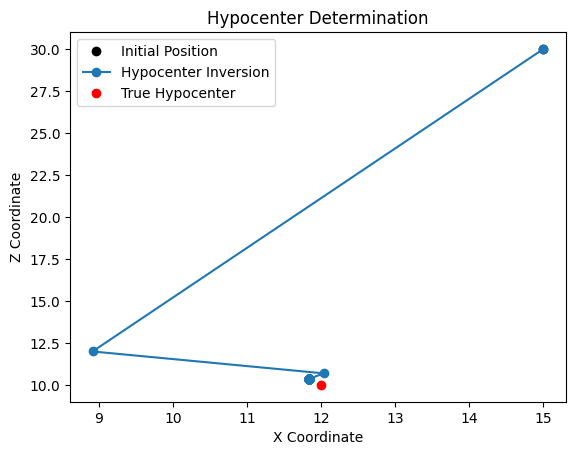

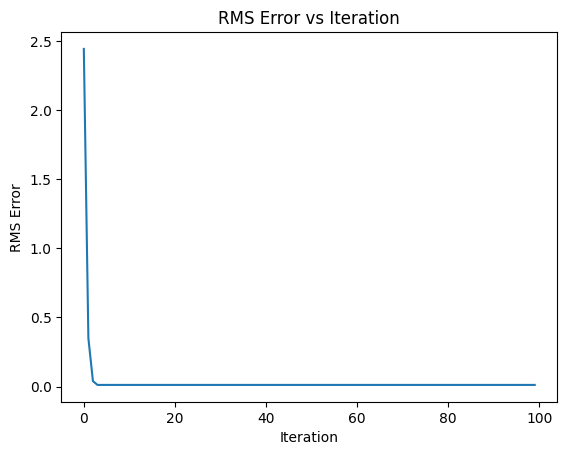

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import copy
from numpy.linalg import inv

# station position
x = [0, 10, 20, 30]
z = [0, 0, 0, 0]
n = len(x)

# True hypocenter
xo = 12
zo = 10
to = 0

# velocity
V = 7

# forward modelling (true travel time)
t = []
for i in range(n):
    t.append((1/V)*np.sqrt((z[i]-zo)**2 + (x[i]-xo)**2))
t = np.array(t)

# add noise
noise = np.random.rand(n) * 0.03 * np.mean(t)
ti = t + noise

# initial guess model
m = [15, 30]   # [x, z]
init_position = copy.deepcopy(m)

# simpan hasil
xhipo = [m[0]]
yhipo = [m[1]]
erms = []

# iterasi inversi non-linear
for niter in range(100):

    gm = []
    dgm_dm1 = []
    dgm_dm2 = []

    for i in range(n):
        r = np.sqrt((x[i]-m[0])**2 + (z[i]-m[1])**2)

        gm.append(to + (1/V)*r)

        dgm_dm1.append((1/V)*(-(x[i]-m[0])/r))
        dgm_dm2.append((1/V)*(-(z[i]-m[1])/r))

    gm = np.array(gm).reshape(n,1)
    ti_reshape = ti.reshape(n,1)

    # Jacobian
    J = np.zeros((n,2))
    for i in range(n):
        J[i,0] = dgm_dm1[i]
        J[i,1] = dgm_dm2[i]

    # update model (least squares)
    JTJ_inv = inv(J.T @ J)
    dm = JTJ_inv @ J.T @ (ti_reshape - gm)

    m = [m[0] + dm[0,0], m[1] + dm[1,0]]

    xhipo.append(m[0])
    yhipo.append(m[1])

    # RMS error
    dt = ti_reshape - gm
    erms.append(np.sqrt(np.mean(dt**2)))

# plotting
plt.figure()
plt.plot(init_position[0], init_position[1], 'o', label='Initial Position', color='black')
plt.plot(xhipo, yhipo, 'o-', label='Hypocenter Inversion')
plt.plot(xo, zo, 'o', color='red', label='True Hypocenter')

plt.title('Hypocenter Determination')
plt.xlabel('X Coordinate')
plt.ylabel('Z Coordinate')
plt.legend()

plt.figure()
plt.plot(erms)
plt.title('RMS Error vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('RMS Error')

plt.show()

Permasalahan 2

Iterasi 1
Model [x, z, t]: [5.02218178 4.99366323 0.84948574]
Error: 2.077580
----------------------------------------
Iterasi 2
Model [x, z, t]: [5.04467794 4.98865184 0.71221605]
Error: 1.894410
----------------------------------------
Iterasi 3
Model [x, z, t]: [5.06728789 4.98515642 0.59105722]
Error: 1.753073
----------------------------------------
Iterasi 4
Model [x, z, t]: [5.08975184 4.9832842  0.48818395]
Error: 1.651704
----------------------------------------
Iterasi 5
Model [x, z, t]: [5.11181489 4.98301135 0.40431422]
Error: 1.583940
----------------------------------------
Iterasi 6
Model [x, z, t]: [5.13330132 4.98418221 0.33842212]
Error: 1.541031
----------------------------------------
Iterasi 7
Model [x, z, t]: [5.15414827 4.98655926 0.28815851]
Error: 1.514587
----------------------------------------
Iterasi 8
Model [x, z, t]: [5.17438691 4.98988719 0.25062387]
Error: 1.498184
----------------------------------------
Iterasi 9
Model [x, z, t]: [5.19410021 4.9939366

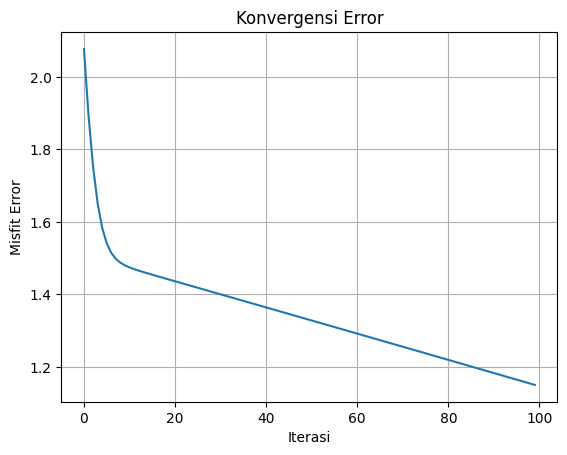

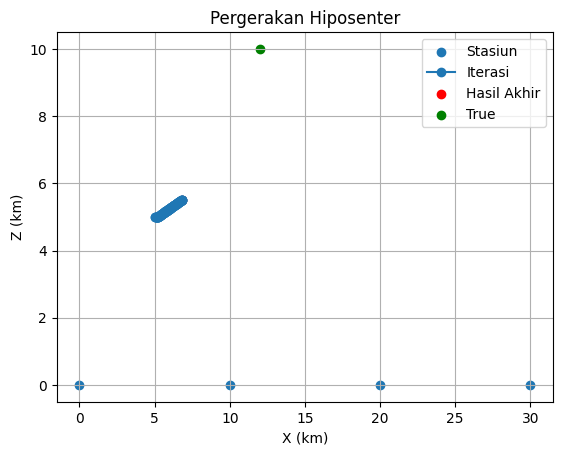

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#DATA DARI SOAL

# Posisi stasiun
x = np.array([0, 10, 20, 30])
z = np.array([0, 0, 0, 0])
n = len(x)

# True hiposenter (dipakai untuk buat data observasi)
xo = 12
zo = 10
to = 0

# Kecepatan gelombang
v = 7


# MEMBUAT DATA OBSERVASI (FORWARD TRUE)
def true_travel_time(xo, zo, to):
    t_obs = []
    for i in range(n):
        d = np.sqrt((x[i] - xo)**2 + (z[i] - zo)**2)
        t = to + d / v
        t_obs.append(t)
    return np.array(t_obs)

t_obs = true_travel_time(xo, zo, to)

# FORWARD MODELLING
def forward_model(m):
    xs, zs, ts = m
    t_model = []
    
    for i in range(n):
        d = np.sqrt((x[i] - xs)**2 + (z[i] - zs)**2)
        t = ts + d / v
        t_model.append(t)
    
    return np.array(t_model)


# MISFIT FUNCTION
def misfit(m):
    t_model = forward_model(m)
    return np.sqrt(np.sum((t_obs - t_model)**2))


# GRADIEN NUMERIK
def gradient(m, h=1e-5):
    grad = np.zeros(3)
    
    for i in range(3):
        m_plus = m.copy()
        m_minus = m.copy()
        
        m_plus[i] += h
        m_minus[i] -= h
        
        grad[i] = (misfit(m_plus) - misfit(m_minus)) / (2*h)
    
    return grad


# GRADIENT DESCENT
def gradient_descent(m_init, lr=0.1, max_iter=100):
    m = m_init.copy()
    
    error_history = []
    model_history = []
    
    for i in range(max_iter):
        grad = gradient(m)
        
        # Update model
        m = m - lr * grad
        
        err = misfit(m)
        
        error_history.append(err)
        model_history.append(m.copy())
        
        print(f"Iterasi {i+1}")
        print(f"Model [x, z, t]: {m}")
        print(f"Error: {err:.6f}")
        print("-"*40)
        
        if err < 1e-5:
            break
    
    return m, error_history, model_history


# RUN INVERSI

# Tebakan awal
m_init = np.array([5.0, 5.0, 1.0])

m_final, error_history, model_history = gradient_descent(
    m_init,
    lr=0.1,
    max_iter=100
)

print("\n=== HASIL AKHIR ===")
print("Hiposenter hasil inversi:", m_final)
print("Hiposenter sebenarnya:", [xo, zo, to])


# PLOT ERROR
plt.figure()
plt.plot(error_history)
plt.xlabel("Iterasi")
plt.ylabel("Misfit Error")
plt.title("Konvergensi Error")
plt.grid()
plt.show()

# PLOT LOKASI HIPOSENTER

model_history = np.array(model_history)

plt.figure()
plt.scatter(x, z, label="Stasiun")
plt.plot(model_history[:,0], model_history[:,1], '-o', label="Iterasi")
plt.scatter(m_final[0], m_final[1], color='red', label="Hasil Akhir")
plt.scatter(xo, zo, color='green', label="True")

plt.xlabel("X (km)")
plt.ylabel("Z (km)")
plt.title("Pergerakan Hiposenter")
plt.legend()
plt.grid()
plt.show()